# 퍼셉트론(Perceptron)과 다층 퍼셉트론

단층 퍼셉트론으로 논리 게이트를 구현하고, XOR로 단층 퍼셉트론의 한계를 시각적으로 확인한 뒤, 다층 퍼셉트론으로 해결하는 과정을 따라가 봅시다!

---

## 0. 환경 설정

In [6]:
%pip install koreanize_matplotlib
# 실행하고 아래 셀에서 오류가 뜬다면 Restart(재시작)를 누른 후에 다시 진행하시면 됩니다.

Note: you may need to restart the kernel to use updated packages.


In [7]:
import koreanize_matplotlib  # 한글 폰트 설정
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import rcParams

rcParams['axes.unicode_minus'] = False

print("라이브러리 로드 완료")

라이브러리 로드 완료


---
## 1. 퍼셉트론이란?

퍼셉트론(Perceptron)은 1957년 Frank Rosenblatt가 고안한 알고리즘으로, **신경망(딥러닝)의 기원**이 되는 선형 이진 분류기(Linear Binary Classifier)입니다.  

### 단층 퍼셉트론 구조

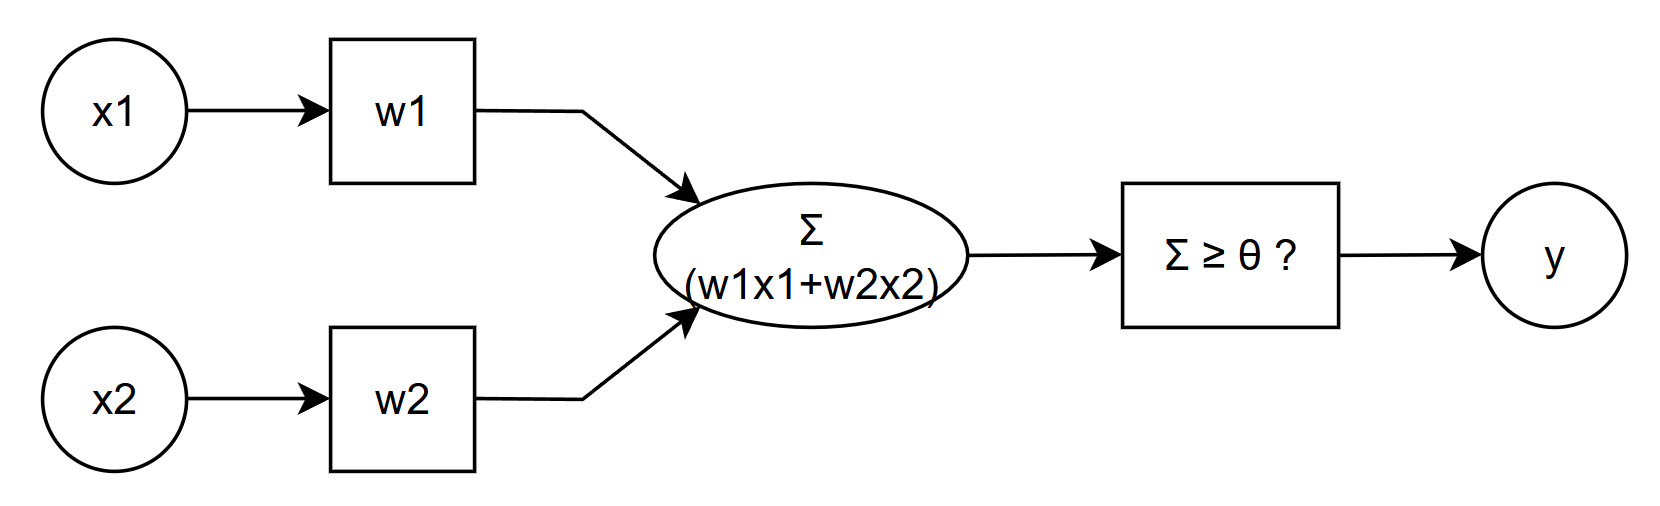

- **입력(x)**: 0 또는 1
- **가중치(w)**: 각 입력의 중요도
- **임계값(θ, theta)**: 이 값을 넘으면 1 출력
- **출력(y)**: 0 또는 1

### 수식

$$y = \begin{cases} 0 & (w_1 x_1 + w_2 x_2 \leq \theta) \\ 1 & (w_1 x_1 + w_2 x_2 > \theta) \end{cases}$$

### 편향(bias) 표현으로 변환

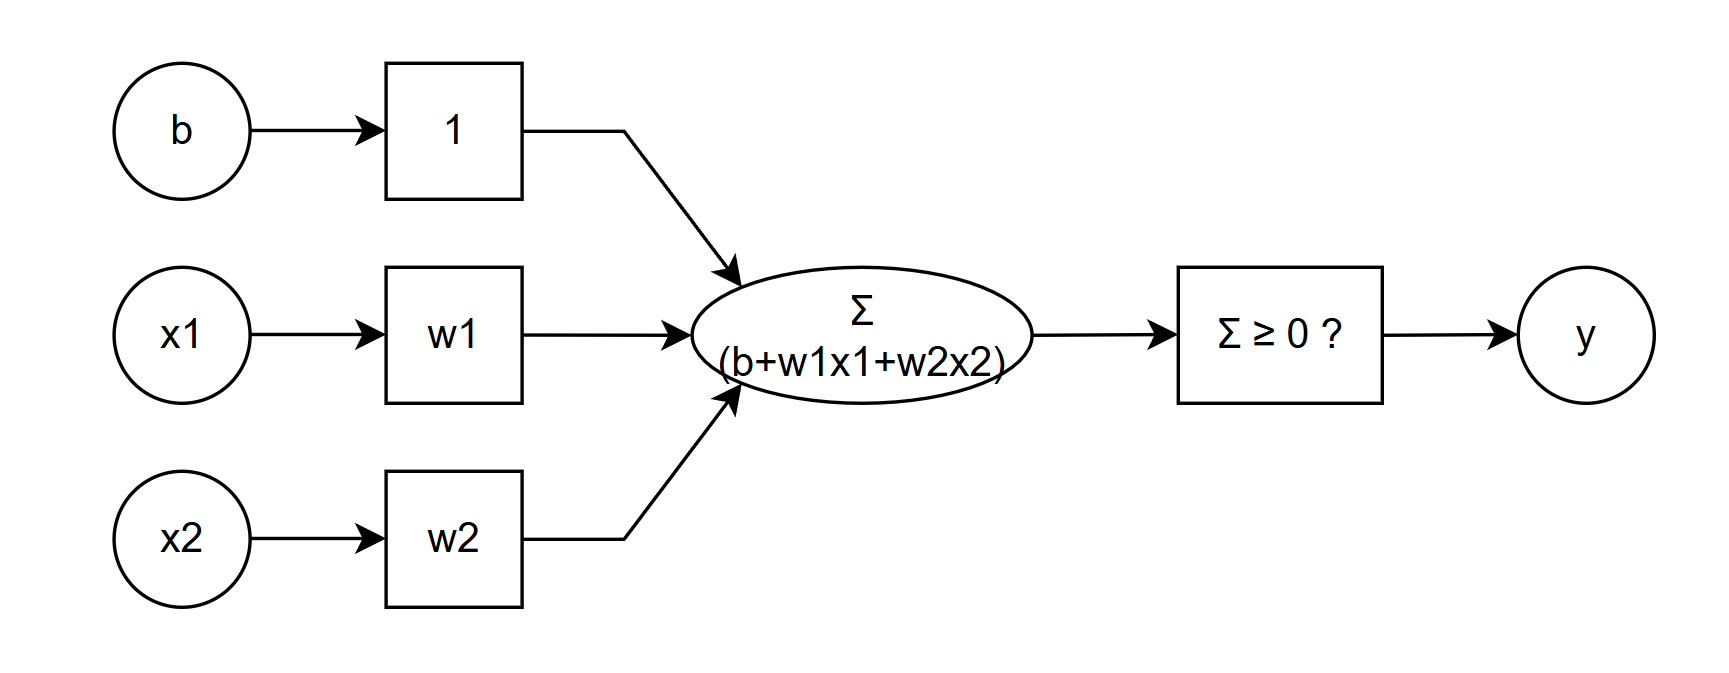

임계값 θ를 좌변으로 넘기면 **편향 b = -θ** 로 표현할 수 있습니다.

$$y = \begin{cases} 0 & (b + w_1 x_1 + w_2 x_2 \leq 0) \\ 1 & (b + w_1 x_1 + w_2 x_2 > 0) \end{cases}$$

> 편향 표현이 코드로 구현하기 더 편하고, 실제 딥러닝 프레임워크도 이 방식을 사용합니다. 저희도 아래에서는 편향 표현으로 볼 거예요.

---
## 2. 단층 퍼셉트론으로 논리 게이트 구현

### 2-1. AND 게이트

| x1 | x2 | y |
|----|----|---|
| 0  | 0  | 0 |
| 1  | 0  | 0 |
| 0  | 1  | 0 |
| 1  | 1  | 1 |

**AND 게이트는 두 입력이 모두 1일 때만 1을 출력**합니다.

#### 가중치/편향은 어떻게 정할까?

AND를 만족하려면 아래 4개 부등식을 **동시에** 만족해야 합니다.

| 입력 | 원하는 출력 | 조건 |
|------|------------|------|
| (0,0) | 0 | $b \leq 0$ |
| (1,0) | 0 | $w_1 + b \leq 0$ |
| (0,1) | 0 | $w_2 + b \leq 0$ |
| (1,1) | 1 | $w_1 + w_2 + b > 0$ |

이 조건을 만족하는 (w1, w2, b) 조합은 **무수히 많습니다.**  
아래에서 조건을 만족하는 값과 그렇지 않은 값을 직접 비교해봅시다.

In [8]:
# AND 게이트: 두 입력이 모두 1일 때만 1을 반환합니다.
def AND(x1, x2):
    w1, w2 = 0.5, 0.5
    b = -0.7
    return 1 if w1*x1 + w2*x2 + b > 0 else 0

In [9]:
# 단층 퍼셉트론 함수 선언
def perceptron(x1, x2, w1, w2, b):
    # 가중합 계산: (w1*x1 + w2*x2 + b)
    # 가중합이 0(임계값)보다 크면 1(활성), 아니면 0(비활성)
    return 1 if w1*x1 + w2*x2 + b > 0 else 0

In [10]:
inputs = [(0,0),(1,0),(0,1),(1,1)] # 입력받을 데이터 쌍 (x1, x2)
and_labels = [0, 0, 0, 1] # AND 연산의 정답! inputs가 둘 다 1일 때만 1이다.

# 평가 함수 선언
def evaluate(w1, w2, b, labels, name=""):
    print(f"\n{'='*65}")
    print(f" {name}  (w1={w1}, w2={w2}, b={b})")
    print(f"{'='*65}")
    print(f" x1 | x2  | 출력  | 정답 |")
    print(f"----|-----|------|------|")
    correct = 0 # 맞힌 개수 저장용 변수
    for (x1, x2), ans in zip(inputs, labels):
        pred = perceptron(x1, x2, w1, w2, b)
        mark = "✅" if pred == ans else "❌"
        if pred == ans: correct += 1
        print(f"  {x1} |  {x2}  |  {pred}   |  {ans}   | {mark}")
    print(f"\n  정확도: {correct}/4")


# 조건을 만족하는 값 (여러 가지 가능!)
# (w1 + w2 + b)가 (1, 1) 상황에서만! 0보다 커야 합니다.
evaluate(0.5, 0.5, -0.7, and_labels, "성공 케이스 1: w1=0.5, w2=0.5, b=-0.7")
evaluate(1.0, 1.0, -1.5, and_labels, "성공 케이스 2: w1=1.0, w2=1.0, b=-1.5")
evaluate(2.0, 2.0, -3.0, and_labels, "성공 케이스 3: w1=2.0, w2=2.0, b=-3.0")

# 조건을 만족하지 못하는 값
# x쌍이 (1, 0)일 때, (0.5 * 1) + (0.5 * 0) - 0.3 = 0.2 이기 때문에 퍼셉트론은 1을 출력합니다.
# (1, 1)일 때만 1을 출력해야 하므로 조건을 만족하지 못하는 상황이에요.
evaluate(0.5, 0.5, -0.3, and_labels, "실패 케이스 1: w1=0.5, w2=0.5, b=-0.3")
evaluate(0.5, 0.5,  0.0, and_labels, "실패 케이스 2: w1=0.5, w2=0.5, b= 0.0")


 성공 케이스 1: w1=0.5, w2=0.5, b=-0.7  (w1=0.5, w2=0.5, b=-0.7)
 x1 | x2  | 출력  | 정답 |
----|-----|------|------|
  0 |  0  |  0   |  0   | ✅
  1 |  0  |  0   |  0   | ✅
  0 |  1  |  0   |  0   | ✅
  1 |  1  |  1   |  1   | ✅

  정확도: 4/4

 성공 케이스 2: w1=1.0, w2=1.0, b=-1.5  (w1=1.0, w2=1.0, b=-1.5)
 x1 | x2  | 출력  | 정답 |
----|-----|------|------|
  0 |  0  |  0   |  0   | ✅
  1 |  0  |  0   |  0   | ✅
  0 |  1  |  0   |  0   | ✅
  1 |  1  |  1   |  1   | ✅

  정확도: 4/4

 성공 케이스 3: w1=2.0, w2=2.0, b=-3.0  (w1=2.0, w2=2.0, b=-3.0)
 x1 | x2  | 출력  | 정답 |
----|-----|------|------|
  0 |  0  |  0   |  0   | ✅
  1 |  0  |  0   |  0   | ✅
  0 |  1  |  0   |  0   | ✅
  1 |  1  |  1   |  1   | ✅

  정확도: 4/4

 실패 케이스 1: w1=0.5, w2=0.5, b=-0.3  (w1=0.5, w2=0.5, b=-0.3)
 x1 | x2  | 출력  | 정답 |
----|-----|------|------|
  0 |  0  |  0   |  0   | ✅
  1 |  0  |  1   |  0   | ❌
  0 |  1  |  1   |  0   | ❌
  1 |  1  |  1   |  1   | ✅

  정확도: 2/4

 실패 케이스 2: w1=0.5, w2=0.5, b= 0.0  (w1=0.5, w2=0.5, b=0.0)
 x1 

위 같은 상황에서 가중치/편향 설정은 사람이 직접 조건을 따져서 수동으로 해야 합니다.  
단순한 AND도 이렇게 번거로운데 복잡한 문제는 어떨까요?  
이게 바로 역전파가 필요한 이유입니다(Section 6에서 다룹니다!).

### 2-2. NAND 게이트

| x1 | x2 | y |
|----|----|---|
| 0  | 0  | 1 |
| 1  | 0  | 1 |
| 0  | 1  | 1 |
| 1  | 1  | 0 |

NAND 게이트는 **AND의 반대**로 두 입력이 모두 1일 때만 0을 출력합니다.  
💡 AND 게이트의 가중치와 편향에 **-1을 곱하면** NAND가 되겠죠?

In [11]:
# NAND 게이트: AND의 반대(Not AND)이므로 가중치/편향에 -1을 곱하면 돼요.
def NAND(x1, x2):
    w1, w2 = -0.5, -0.5   # AND의 가중치에 -1 곱
    b = 0.7               # AND의 편향에 -1 곱
    output = w1*x1 + w2*x2 + b
    return 1 if output > 0 else 0

print("< NAND 게이트 >")
print("x1 | x2 | y")
print("---|----|--")
for x1, x2 in [(0,0),(1,0),(0,1),(1,1)]:
    print(f" {x1} |  {x2} | {NAND(x1, x2)}")

< NAND 게이트 >
x1 | x2 | y
---|----|--
 0 |  0 | 1
 1 |  0 | 1
 0 |  1 | 1
 1 |  1 | 0


### 2-3. OR 게이트

| x1 | x2 | y |
|----|----|---|
| 0  | 0  | 0 |
| 1  | 0  | 1 |
| 0  | 1  | 1 |
| 1  | 1  | 1 |

**OR 게이트는 하나 이상의 입력이 1이면 1을 출력**합니다.

In [12]:
# OR 게이트: 하나 이상 1이면 1을 반환해요.
def OR(x1, x2):
    w1, w2 = 0.5, 0.5   # 가중치
    b = -0.3            # 편향 (x 중 하나만 켜져도 통과될 수 있도록 작게 설정해주기)
    output = w1*x1 + w2*x2 + b
    return 1 if output > 0 else 0

print("=== OR 게이트 ===")
print("x1 | x2 | y")
print("-----------")
for x1, x2 in [(0,0),(1,0),(0,1),(1,1)]:
    print(f" {x1} |  {x2} | {OR(x1, x2)}")

=== OR 게이트 ===
x1 | x2 | y
-----------
 0 |  0 | 0
 1 |  0 | 1
 0 |  1 | 1
 1 |  1 | 1


### 단층 퍼셉트론 정리

| 게이트 | w1   | w2   | b    | 조건 |
|--------|------|------|------|------|
| AND    |  0.5 |  0.5 | -0.7 | 둘 다 1일 때만 통과 |
| NAND   | -0.5 | -0.5 |  0.7 | AND의 가중치/편향 × -1 |
| OR     |  0.5 |  0.5 | -0.3 | 임계값을 낮춰 하나만 켜져도 통과 |


가중치와 편향 값만 바꾸면 서로 다른 논리 게이트를 구현할 수 있습니다.

---
## 3. 단층 퍼셉트론의 한계 — XOR 문제

### XOR 진리표

| x1 | x2 | y |
|----|----|---|
| 0  | 0  | 0 |
| 1  | 0  | 1 |
| 0  | 1  | 1 |
| 1  | 1  | 0 |

XOR은 **두 입력이 다를 때만 1을 출력**합니다.

### 3-1. 단층 퍼셉트론으로 XOR 시도

In [13]:
xor_labels = [0, 1, 1, 0]

print("XOR 구현을 위해 여러 (w1, w2, b) 조합을 시도해봅시다.\n")

# 다양한 조합을 시도해봐도 항상 최대 3/4
candidates = [
    (1.0,  1.0, -0.5, "대칭 가중치, 낮은 임계값"),
    (1.0,  1.0, -1.5, "대칭 가중치, 높은 임계값"),
    (1.0, -1.0,  0.0, "비대칭 가중치"),
    (0.5,  0.5, -0.3, "OR에 가까운 값"),
]

for w1, w2, b, desc in candidates:
    correct = sum(perceptron(x1, x2, w1, w2, b) == ans
                    for (x1, x2), ans in zip(inputs, xor_labels))
    print(f" [{desc}]  w1={w1:+.1f}, w2={w2:+.1f}, b={b:+.1f}  →  {correct}/4")

print("\n❌ 선형 조합으로는 XOR을 만족할 수 없습니다.")

XOR 구현을 위해 여러 (w1, w2, b) 조합을 시도해봅시다.

 [대칭 가중치, 낮은 임계값]  w1=+1.0, w2=+1.0, b=-0.5  →  3/4
 [대칭 가중치, 높은 임계값]  w1=+1.0, w2=+1.0, b=-1.5  →  1/4
 [비대칭 가중치]  w1=+1.0, w2=-1.0, b=+0.0  →  3/4
 [OR에 가까운 값]  w1=+0.5, w2=+0.5, b=-0.3  →  3/4

❌ 선형 조합으로는 XOR을 만족할 수 없습니다.


### 3-2. 왜 안 될까? — 시각화로 확인해봅시다.

퍼셉트론은 결국 **직선(초평면) 하나**로 데이터를 분류하는 모델입니다.  
AND, NAND, OR은 직선 하나로 분리할 수 있지만, XOR은 그렇지 않습니다.

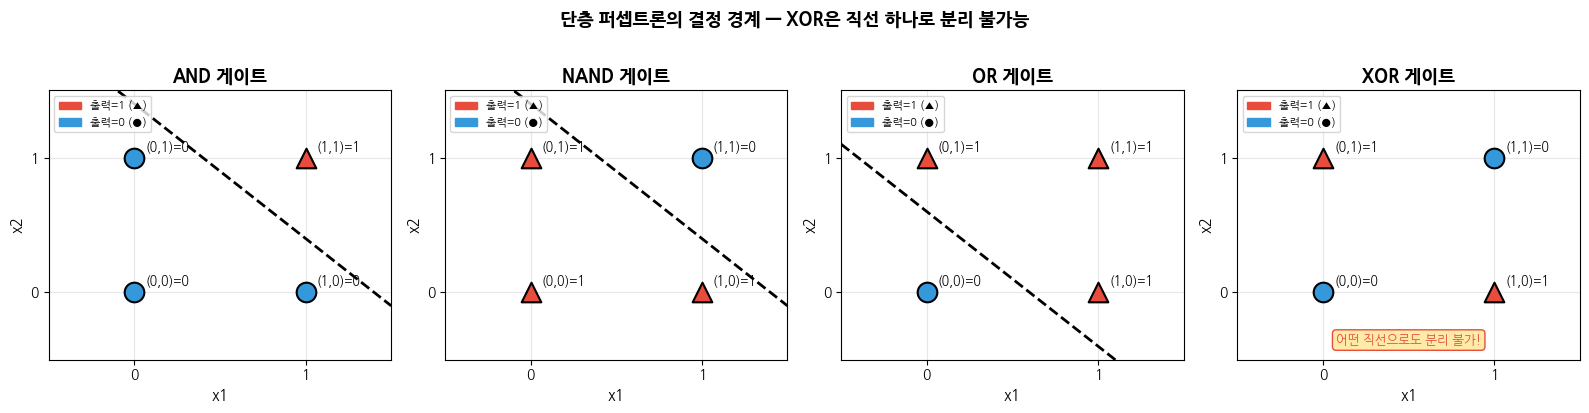

📌 AND/NAND/OR는 직선 하나(점선)로 분리되지만, XOR은 불가능합니다.


In [14]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

gates = {
    'AND':  {'labels': [0,0,0,1], 'w': [0.5, 0.5], 'b': -0.7},
    'NAND': {'labels': [1,1,1,0], 'w': [-0.5,-0.5], 'b': 0.7},
    'OR':   {'labels': [0,1,1,1], 'w': [0.5, 0.5], 'b': -0.3},
    'XOR':  {'labels': [0,1,1,0], 'w': None, 'b': None},
}

points = [(0,0),(1,0),(0,1),(1,1)]

for ax, (name, info) in zip(axes, gates.items()):
    for (x1, x2), label in zip(points, info['labels']):
        color = '#e74c3c' if label == 1 else '#3498db'
        marker = '^' if label == 1 else 'o'
        ax.scatter(x1, x2, c=color, marker=marker, s=200, zorder=5,
                   edgecolors='black', linewidths=1.5)
        ax.annotate(f'({x1},{x2})={label}', (x1, x2),
                    textcoords='offset points', xytext=(8, 5), fontsize=9)

    if info['w'] is not None:
        w1_v, w2_v, b_v = info['w'][0], info['w'][1], info['b']
        x_vals = np.linspace(-0.5, 1.5, 200)
        if abs(w2_v) > 1e-9:
            y_vals = (-w1_v * x_vals - b_v) / w2_v
            ax.plot(x_vals, y_vals, 'k--', linewidth=2, label='결정 경계')
    else:
        ax.text(0.5, -0.38, '어떤 직선으로도 분리 불가!',
                ha='center', fontsize=9, color='#e74c3c',
                bbox=dict(boxstyle='round,pad=0.3', fc='#ffeaa7', ec='#e74c3c'))

    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 1.5)
    ax.set_xlabel('x1', fontsize=11)
    ax.set_ylabel('x2', fontsize=11)
    ax.set_title(f'{name} 게이트', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])

    red_patch  = mpatches.Patch(color='#e74c3c', label='출력=1 (▲)')
    blue_patch = mpatches.Patch(color='#3498db', label='출력=0 (●)')
    ax.legend(handles=[red_patch, blue_patch], fontsize=8, loc='upper left')

fig.suptitle('단층 퍼셉트론의 결정 경계 — XOR은 직선 하나로 분리 불가능', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print("📌 AND/NAND/OR는 직선 하나(점선)로 분리되지만, XOR은 불가능합니다.")

### 💡 선형 분리 가능성 (Linear Separability)

- **AND / NAND / OR** → 직선 하나로 0과 1을 분리할 수 있음 = **선형 분리 가능**
- **XOR** → 어떤 직선을 그어도 0과 1을 완전히 분리할 수 없음 = **선형 분리 불가능**

단층 퍼셉트론은 선형 분리 가능한 문제만 풀 수 있습니다.  
그렇다면 XOR은 어떻게 해결해야 할까요?

---
## 4. 다층 퍼셉트론(MLP)으로 XOR 해결

### 아이디어: 기존 게이트를 조합하자!

XOR은 아래와 같이 NAND, OR, AND의 조합으로 표현할 수 있습니다.

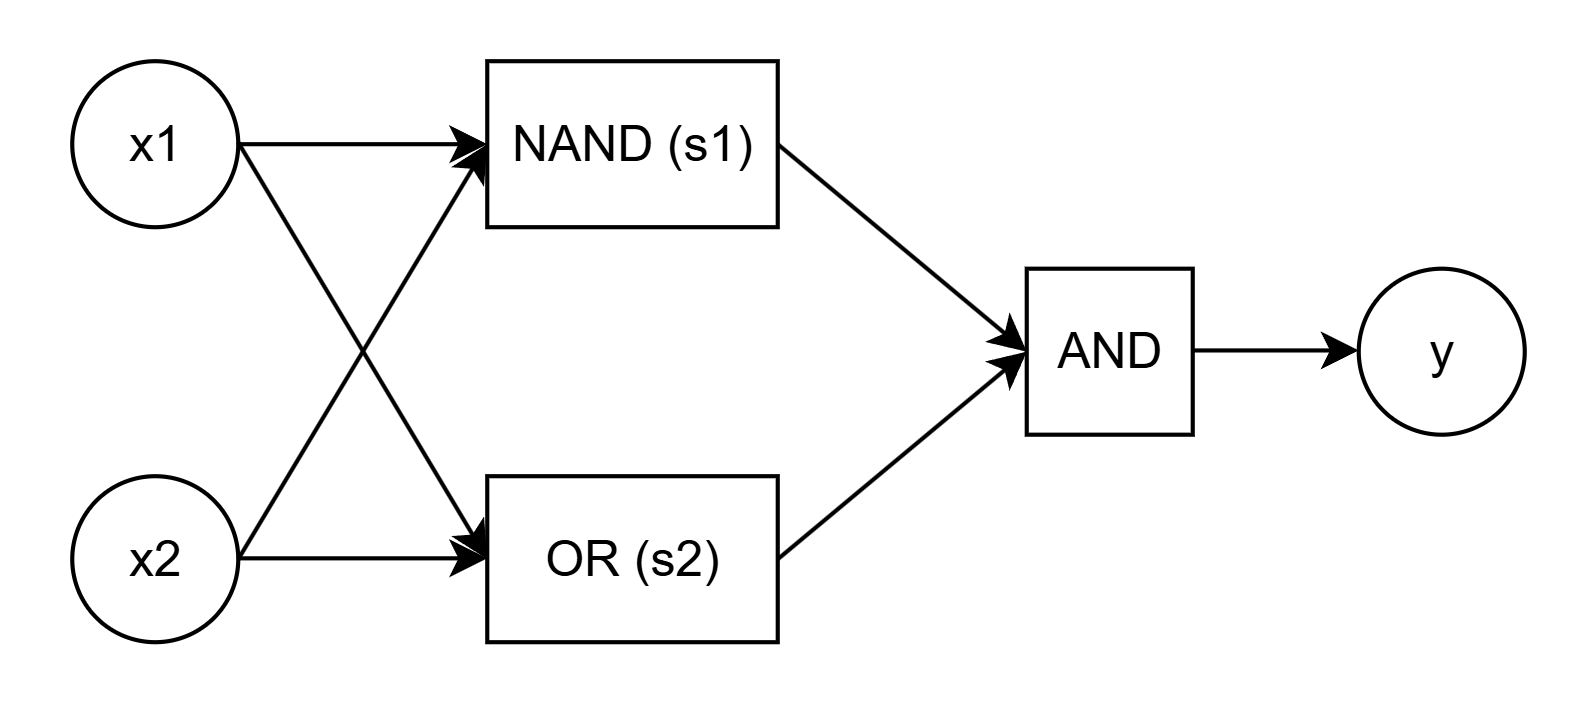

**진리표로 확인해볼까요?**

| x1 | x2 | s1=NAND | s2=OR | y=AND(s1,s2) |
|----|----|---------|----- |--------------|
| 0  | 0  |    1    |   0  |      0       |
| 1  | 0  |    1    |   1  |      1       |
| 0  | 1  |    1    |   1  |      1       |
| 1  | 1  |    0    |   1  |      0       |

NAND, OR, AND를 활용한 게이트 조합이 XOR과 일치하는 걸 확인할 수 있어요.

In [15]:
# 다층 퍼셉트론으로 XOR 구현: NAND + OR → AND
def XOR(x1, x2):
    s1 = NAND(x1, x2)   # 1층: NAND
    s2 = OR(x1, x2)     # 1층: OR
    y  = AND(s1, s2)    # 2층: AND
    return y

print("=== 다층 퍼셉트론 XOR ===")
print(" x1 | x2 | s1(NAND) | s2(OR) | y(AND) | 정답")
print("----|----|----------|--------|--------|-----")
correct = 0
for (x1, x2), ans in zip(inputs, xor_labels):
    s1 = NAND(x1, x2)
    s2 = OR(x1, x2)
    y  = AND(s1, s2)
    mark = "✅" if y == ans else "❌"
    if y == ans: correct += 1
    print(f"  {x1} |  {x2} |    {s1}     |    {s2}   |   {y}    |  {ans}  {mark}")
print(f"\n정확도: {correct}/4 ({correct/4*100:.0f}%)")

=== 다층 퍼셉트론 XOR ===
 x1 | x2 | s1(NAND) | s2(OR) | y(AND) | 정답
----|----|----------|--------|--------|-----
  0 |  0 |    1     |    0   |   0    |  0  ✅
  1 |  0 |    1     |    1   |   1    |  1  ✅
  0 |  1 |    1     |    1   |   1    |  1  ✅
  1 |  1 |    0     |    1   |   0    |  0  ✅

정확도: 4/4 (100%)


### 4-2. 다층 퍼셉트론 구조 시각화

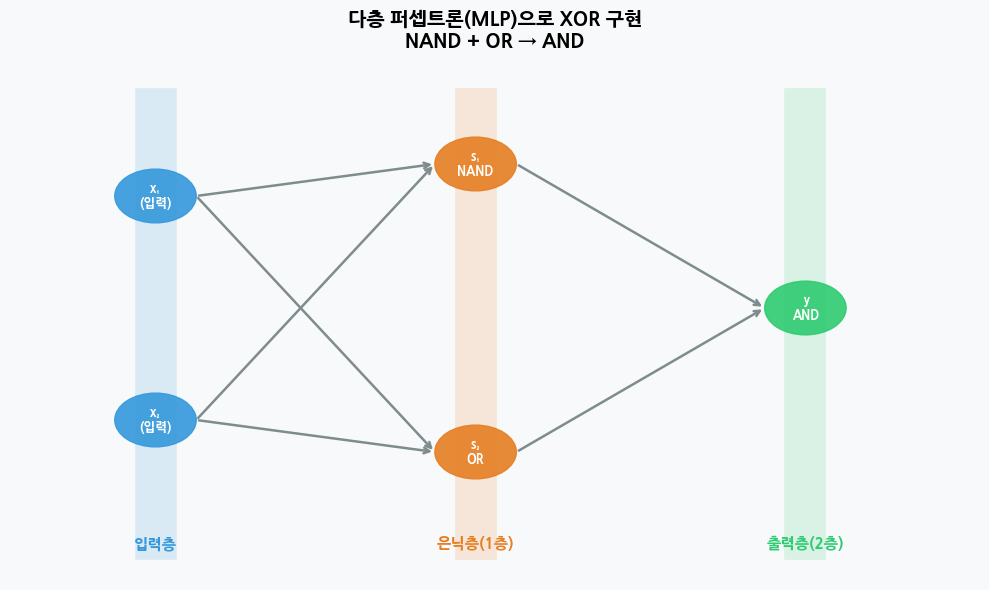

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlim(0, 10)
ax.set_ylim(0, 8)
ax.axis('off')
ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('#f8f9fa')

nodes = {
    'x1': (1.5, 6.0), 'x2': (1.5, 2.5),
    's1': (4.8, 6.5), 's2': (4.8, 2.0),
    'y':  (8.2, 4.25)
}
colors = {
    'x1': '#3498db', 'x2': '#3498db',
    's1': '#e67e22', 's2': '#e67e22',
    'y':  '#2ecc71'
}
labels = {
    'x1': 'x₁\n(입력)', 'x2': 'x₂\n(입력)',
    's1': 's₁\nNAND', 's2': 's₂\nOR',
    'y':  'y\nAND'
}

edges = [('x1','s1'),('x1','s2'),('x2','s1'),('x2','s2'),('s1','y'),('s2','y')]
for src, dst in edges:
    x0, y0 = nodes[src]
    x1, y1 = nodes[dst]
    ax.annotate('', xy=(x1-0.42, y1), xytext=(x0+0.42, y0),
                arrowprops=dict(arrowstyle='->', color='#7f8c8d', lw=1.8))

for name, (cx, cy) in nodes.items():
    circle = plt.Circle((cx, cy), 0.42, color=colors[name], zorder=5, alpha=0.9)
    ax.add_patch(circle)
    ax.text(cx, cy, labels[name], ha='center', va='center',
            fontsize=9, color='white', fontweight='bold', zorder=6)

for x, label, color in [(1.5,'입력층','#3498db'),(4.8,'은닉층(1층)','#e67e22'),(8.2,'출력층(2층)','#2ecc71')]:
    ax.text(x, 0.5, label, ha='center', fontsize=11, color=color, fontweight='bold')
    ax.axvline(x=x, ymin=0.08, ymax=0.92, color=color, alpha=0.15, linewidth=30)

ax.set_title('다층 퍼셉트론(MLP)으로 XOR 구현\nNAND + OR → AND', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

---
## 5. numpy로 행렬 연산 표현 (딥러닝 연결)

지금까지는 게이트를 하나씩 함수로 구현했지만,  
실제 딥러닝에서는 **행렬 곱(Matrix Multiplication)**으로 한 번에 처리합니다.

퍼셉트론의 연산: $\mathbf{y} = \mathbf{W} \cdot \mathbf{x} + \mathbf{b}$

In [17]:
# 계단 함수 (퍼셉트론의 활성화 함수입니다)
def step_function(x):
    return (x > 0).astype(int)

In [18]:
def XOR_matrix(x1, x2):
    """
    행렬 연산으로 XOR 구현
    1층: NAND + OR 동시 계산
    2층: AND 계산
    """
    X = np.array([x1, x2])

    # 1층: 각 행이 하나의 뉴런 (NAND, OR)
    W1 = np.array([[-0.5, -0.5],   # NAND 뉴런
                    [ 0.5,  0.5]])  # OR 뉴런
    b1 = np.array([0.7, -0.3])     # [NAND 편향, OR 편향]

    # 2층: AND 뉴런
    W2 = np.array([0.5, 0.5])
    b2 = np.array([-0.7])

    A1 = W1 @ X + b1          # 1층 선형 결합
    Z1 = step_function(A1)    # 1층 활성화 → s1, s2
    A2 = W2 @ Z1 + b2         # 2층 선형 결합
    Z2 = step_function(A2)    # 2층 활성화 → y

    return Z1, Z2[0]

In [19]:
print("< 행렬 연산 XOR >")
print(" x1 | x2 | s1(NAND) | s2(OR) | y | 정답")
print("----|----|----------|--------|---|-----")
correct = 0
for (x1, x2), ans in zip(inputs, xor_labels):
    (s1, s2), y = XOR_matrix(x1, x2)
    mark = "✅" if y == ans else "❌"
    if y == ans: correct += 1
    print(f"  {x1} |  {x2} |    {s1}     |    {s2}   | {y} |  {ans}  {mark}")
print(f"\n정확도: {correct}/4 ({correct/4*100:.0f}%)")

< 행렬 연산 XOR >
 x1 | x2 | s1(NAND) | s2(OR) | y | 정답
----|----|----------|--------|---|-----
  0 |  0 |    1     |    0   | 0 |  0  ✅
  1 |  0 |    1     |    1   | 1 |  1  ✅
  0 |  1 |    1     |    1   | 1 |  1  ✅
  1 |  1 |    0     |    1   | 0 |  0  ✅

정확도: 4/4 (100%)


---
## 6. 한계: 가중치를 직접 설정해야 하는 문제

지금까지 AND, NAND, OR, XOR 모두 가중치와 편향을 **사람이 직접** 정했습니다.

단순한 논리 게이트는 그게 가능하지만, 현실에서는 그렇지 않습니다...

In [20]:
# 현실 문제 규모 비교
print("=" * 50)
print(" 문제               입력 수     설정해야 할 파라미터")
print("-" * 50)
print(f" AND/OR 게이트       2개         3개 (w1, w2, b)") # 이정도는 할만 합니다.
print(f" 28×28 손글씨 분류   784개       수백~수천 개") # 단순 28×28 해상도인데도 파라미터 수가 어마무시하죠?
print(f" 이미지 분류 (ResNet) 수십만 개   2,500만 개 이상")
print(f" ChatGPT (GPT-3)     -           1,750억 개")
print("=" * 50)
print("\n이 정도 규모의 파라미터를 사람이 직접 설정하는 건 불가능하겠죠?")

 문제               입력 수     설정해야 할 파라미터
--------------------------------------------------
 AND/OR 게이트       2개         3개 (w1, w2, b)
 28×28 손글씨 분류   784개       수백~수천 개
 이미지 분류 (ResNet) 수십만 개   2,500만 개 이상
 ChatGPT (GPT-3)     -           1,750억 개

이 정도 규모의 파라미터를 사람이 직접 설정하는 건 불가능하겠죠?


### 해결책: 역전파(Backpropagation)로 자동 학습

딥러닝에서는 가중치를 사람이 설정하는 대신, **데이터로부터 자동으로 학습**합니다.  
이것이 가능한 핵심 알고리즘이 바로 저희가 배웠던 **역전파**(Backpropagation)입니다.  
(복습하시는 걸 정말정말정말 추천드려요!!)


① 순전파(Forward pass)  
   입력 → 현재 가중치로 예측값 계산

② 손실 계산(Loss)  
   예측값과 정답의 차이(오차) 계산

③ 역전파(Backward pass)  
   오차를 출력층 → 입력층 방향으로 전파  
   각 가중치가 오차에 얼마나 기여했는지(기울기) 계산

④ 가중치 업데이트  
   기울기를 이용해 **오차를 줄이는 방향으로** 가중치 조정

⑤ ①~④를 수천~수만 번 반복 → 가중치가 점점 최적값으로 수렴
  

아래에서 XOR을 역전파로 **스스로 학습**하는 과정을 직접 확인해봅시다.

In [21]:
# 시그모이드 활성화 함수를 써볼게요
# (역전파를 하려면 미분 가능한 함수를 사용해야 해요! 연쇄법칙을 떠올려 보세요)
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_deriv(x):
    s = sigmoid(x)
    return s * (1 - s)

# XOR 데이터
X_train = np.array([[0,0],[1,0],[0,1],[1,1]], dtype=float)
y_train = np.array([[0],[1],[1],[0]],          dtype=float)

# 가중치 랜덤 초기화 (사람이 설정하지 않음!)
np.random.seed(42)
W1 = np.random.randn(2, 4) * 0.5   # 입력층 → 은닉층 (뉴런 4개)
b1 = np.zeros((1, 4))
W2 = np.random.randn(4, 1) * 0.5   # 은닉층 → 출력층
b2 = np.zeros((1, 1))

lr = 0.5      # 학습률
epochs = 5000 # 학습 반복 횟수
loss_history = []

for epoch in range(epochs): # 행렬 곱을 사용합시다
    # ① 순전파
    A1 = X_train @ W1 + b1
    Z1 = sigmoid(A1)
    A2 = Z1 @ W2 + b2
    Z2 = sigmoid(A2)

    # ② 손실 (MSE를 사용해줄게요)
    loss = np.mean((y_train - Z2) ** 2)
    loss_history.append(loss)

    # ③ 역전파
    dZ2 = -2 * (y_train - Z2) * sigmoid_deriv(A2)
    dW2 = Z1.T @ dZ2
    db2 = np.sum(dZ2, axis=0, keepdims=True)

    dZ1 = (dZ2 @ W2.T) * sigmoid_deriv(A1)
    dW1 = X_train.T @ dZ1
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    # ④ 가중치 업데이트
    W2 -= lr * dW2;  b2 -= lr * db2
    W1 -= lr * dW1;  b1 -= lr * db1

# 결과 확인
print("< 역전파로 학습한 XOR >")
print(" x1 | x2 |  예측값   |  예측(반올림)  | 정답")
print("----|----|----------|--------------|-----")
A1_f = X_train @ W1 + b1
Z1_f = sigmoid(A1_f)
pred = sigmoid(Z1_f @ W2 + b2)
for i, ((x1, x2), ans) in enumerate(zip(X_train, y_train)):
    p = pred[i][0]
    r = round(p)
    mark = "✅" if r == int(ans[0]) else "❌"
    print(f"  {int(x1)} |  {int(x2)} |  {p:.4f}  |      {r}       |  {int(ans[0])}  {mark}")
print(f"\n최종 손실(loss): {loss_history[-1]:.6f}")

< 역전파로 학습한 XOR >
 x1 | x2 |  예측값   |  예측(반올림)  | 정답
----|----|----------|--------------|-----
  0 |  0 |  0.0187  |      0       |  0  ✅
  1 |  0 |  0.9844  |      1       |  1  ✅
  0 |  1 |  0.9845  |      1       |  1  ✅
  1 |  1 |  0.0151  |      0       |  0  ✅

최종 손실(loss): 0.000265


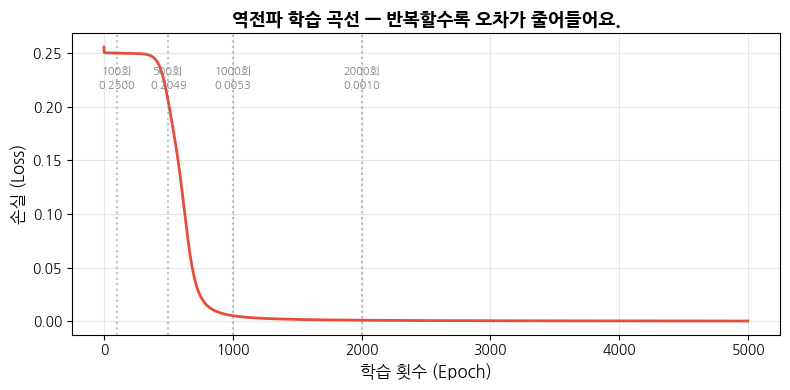

📌 학습이 반복될수록 손실이 0에 가까워집니다.


In [22]:
# 학습 곡선 시각화
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(loss_history, color='#e74c3c', linewidth=2)
ax.set_xlabel('학습 횟수 (Epoch)', fontsize=12)
ax.set_ylabel('손실 (Loss)', fontsize=12)
ax.set_title('역전파 학습 곡선 — 반복할수록 오차가 줄어들어요.', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)

# 주요 지점 표시
for epoch_mark in [100, 500, 1000, 2000]:
    ax.axvline(x=epoch_mark, color='gray', linestyle=':', alpha=0.5)
    ax.text(epoch_mark, max(loss_history)*0.85,
            f'{epoch_mark}회\n{loss_history[epoch_mark-1]:.4f}',
            ha='center', fontsize=8, color='gray')

plt.tight_layout()
plt.show()
print("📌 학습이 반복될수록 손실이 0에 가까워집니다.")

너무 신기하고 재밌지 않나요?

### 핵심 비교

| | 단층/다층 퍼셉트론 (지금까지) | 딥러닝 (역전파) |
|--|------|------|
| **가중치 설정** | 사람이 직접 | 데이터로부터 자동 학습 |
| **적용 범위** | 단순 논리 게이트 | 이미지, 언어, 음성 등 복잡한 문제 |
| **파라미터 수** | 수 개 | 수억 ~ 수천억 개 |
| **활성화 함수** | 계단 함수 (미분 불가) | 시그모이드, ReLU 등 (미분 가능) |

---
## 7. 전체 정리

| 항목 | 내용 |
|------|------|
| **단층 퍼셉트론** | 직선(초평면) 하나로 데이터를 분류 |
| **구현 가능** | AND, NAND, OR (선형 분리 가능) |
| **구현 불가** | XOR (선형 분리 불가능) |
| **해결책** | **다층 퍼셉트론** — 레이어를 쌓아 비선형 경계 표현 |
| **남은 한계** | 가중치를 사람이 직접 설정해야 함 |
| **딥러닝의 핵심** | **역전파**로 가중치를 데이터에서 자동 학습 |

```
단층 퍼셉트론 → 다층 퍼셉트론 → 역전파(자동 학습) → 딥러닝
     AND/OR       XOR 해결        가중치 자동 설정    현대 AI
```

흐름을 이해하시면 됩니다!!

### 과제하시느라 고생 많으셨습니다~!